m_k: [ 25  31  39  48  61  76  95 119 149 186 232]
log(m_k): [3.219 3.434 3.664 3.871 4.111 4.331 4.554 4.779 5.004 5.226 5.447]

Simulating theta* = 0.5
  simulation 500 / 5000
  simulation 1000 / 5000
  simulation 1500 / 5000
  simulation 2000 / 5000
  simulation 2500 / 5000
  simulation 3000 / 5000
  simulation 3500 / 5000
  simulation 4000 / 5000
  simulation 4500 / 5000
  simulation 5000 / 5000

Simulating theta* = 1.0
  simulation 500 / 5000
  simulation 1000 / 5000
  simulation 1500 / 5000
  simulation 2000 / 5000
  simulation 2500 / 5000
  simulation 3000 / 5000
  simulation 3500 / 5000
  simulation 4000 / 5000
  simulation 4500 / 5000
  simulation 5000 / 5000

Simulating theta* = 1.5
  simulation 500 / 5000
  simulation 1000 / 5000
  simulation 1500 / 5000
  simulation 2000 / 5000
  simulation 2500 / 5000
  simulation 3000 / 5000
  simulation 3500 / 5000
  simulation 4000 / 5000
  simulation 4500 / 5000
  simulation 5000 / 5000


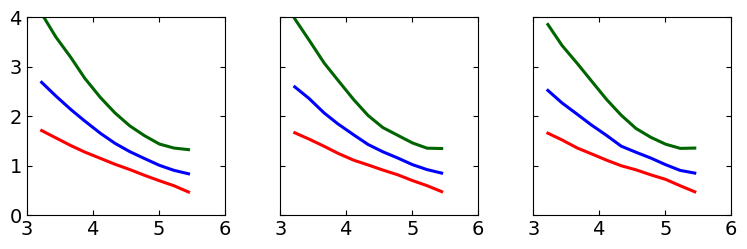

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

# =====================================================
# Settings from slides / Figure 46
# =====================================================

B = 5000          # use 500 for testing, 5000 for final
d = 6             # 6-dimensional Clayton copula

m0 = 20
c = 1.25
K = 11

theta_values = [0.5, 1.0, 1.5]
rho_values = [0.2, 0.5, 1.0]

k_values = np.arange(1, K + 1)

# Slide says m_k = [m0 c^k], integer part
m_values = np.array([int(np.floor(m0 * c**k)) for k in k_values])
log_m_values = np.log(m_values)

print("m_k:", m_values)
print("log(m_k):", np.round(log_m_values, 3))

rng = np.random.default_rng(12345)


# =====================================================
# 1. Simulate d-dimensional Clayton copula
# =====================================================

def simulate_clayton_d(theta, n, d, rng):
    """
    Simulate n observations from a d-dimensional Clayton copula.

    Marshall-Olkin representation:
        W ~ Gamma(1/theta, 1)
        E_j ~ Exp(1)
        U_j = (1 + E_j/W)^(-1/theta)
    """

    W = rng.gamma(shape=1.0 / theta, scale=1.0, size=(n, 1))
    E = rng.exponential(scale=1.0, size=(n, d))

    U = (1.0 + E / W) ** (-1.0 / theta)

    return U


# =====================================================
# 2. d-dimensional Clayton log-likelihood
# =====================================================

def clayton_log_density_d(U, theta):
    """
    d-dimensional Clayton copula log-density.

    c_theta(u)
      = prod_{j=1}^{d-1}(1 + j theta)
        * prod_i u_i^(-theta - 1)
        * (sum_i u_i^(-theta) - d + 1)^(-d - 1/theta)
    """

    eps = 1e-12
    U = np.clip(U, eps, 1.0 - eps)

    n, d = U.shape

    S = np.sum(U ** (-theta), axis=1) - d + 1.0

    log_const = np.sum(np.log(1.0 + theta * np.arange(1, d)))

    log_density = (
        log_const
        + (-theta - 1.0) * np.sum(np.log(U), axis=1)
        + (-d - 1.0 / theta) * np.log(S)
    )

    return log_density


def clayton_loglik_d(U, theta):
    return np.sum(clayton_log_density_d(U, theta))


# =====================================================
# 3. MLE for Clayton theta
# =====================================================

def estimate_theta_mle(U):
    """
    Maximum likelihood estimator of Clayton theta.
    """

    def objective(theta):
        return -clayton_loglik_d(U, theta)

    result = minimize_scalar(
        objective,
        bounds=(0.02, 10.0),
        method="bounded",
        options={"xatol": 1e-3}
    )

    return result.x


# =====================================================
# 4. Interval construction from the slide
# =====================================================

def get_interval_I(U_full, m_k):
    """
    I_k = [t0 - m_k, t0]

    In array form, this means the last m_k observations.
    """

    return U_full[-m_k:]


def get_block_J(U_full, m_values, k_idx):
    """
    J_k = [t0 - m_k, t0 - m_{k-1}]

    Included for consistency with the slide notation.
    The critical-value statistic below is based on nested I_k.
    """

    m_k = m_values[k_idx]

    if k_idx == 0:
        return U_full[-m_k:]

    m_prev = m_values[k_idx - 1]

    return U_full[-m_k:-m_prev]


# =====================================================
# 5. rho -> quantile level
# =====================================================

def rho_to_quantile(rho):
    """
    Slide says rho = 0.2, 0.5, 1.0 from top to bottom.

    Therefore:
        rho=0.2 gives largest critical values,
        rho=0.5 gives middle critical values,
        rho=1.0 gives smallest critical values.

    exp(-rho):
        rho=0.2 -> 0.819
        rho=0.5 -> 0.607
        rho=1.0 -> 0.368
    """

    return np.exp(-rho)


# =====================================================
# 6. Likelihood-ratio statistics
# =====================================================

def lr_stat_against_theta_star(U, theta_hat, theta_star):
    """
    Local LR statistic comparing theta_hat with true theta_star:

        T = sqrt(2 [L(theta_hat) - L(theta_star)]_+)
    """

    ll_hat = clayton_loglik_d(U, theta_hat)
    ll_star = clayton_loglik_d(U, theta_star)

    lr = 2.0 * max(ll_hat - ll_star, 0.0)

    return np.sqrt(lr)


def lr_distance_on_larger_interval(U_large, theta_large, theta_small):
    """
    LR distance between theta_large and theta_small,
    evaluated on the larger interval:

        D = sqrt(2 [L_large(theta_large) - L_large(theta_small)]_+)

    theta_large is the MLE on U_large.
    """

    ll_large = clayton_loglik_d(U_large, theta_large)
    ll_small = clayton_loglik_d(U_large, theta_small)

    lr = 2.0 * max(ll_large - ll_small, 0.0)

    return np.sqrt(lr)


# =====================================================
# 7. Monte Carlo critical values
# =====================================================

critical_values = {}

for theta_star in theta_values:

    print(f"\nSimulating theta* = {theta_star}")

    # T[b, k] = local LR statistic at interval I_k
    T = np.zeros((B, K))

    # D[b, k, j] = distance between I_k estimate and I_j estimate, j > k
    D = np.zeros((B, K, K))

    max_m = int(m_values[-1])

    for b in range(B):

        if (b + 1) % 500 == 0:
            print(f"  simulation {b + 1} / {B}")

        # Under calibration/null: theta is constant, no jump
        U_full = simulate_clayton_d(theta_star, max_m, d, rng)

        I_samples = []
        theta_hat = np.zeros(K)

        # Estimate theta on each nested interval I_k
        for k_idx, m_k in enumerate(m_values):

            U_I_k = get_interval_I(U_full, m_k)
            I_samples.append(U_I_k)

            theta_hat[k_idx] = estimate_theta_mle(U_I_k)

            T[b, k_idx] = lr_stat_against_theta_star(
                U=U_I_k,
                theta_hat=theta_hat[k_idx],
                theta_star=theta_star
            )

        # Pairwise nested-interval LR distances
        for k_idx in range(K):

            theta_k = theta_hat[k_idx]

            for j_idx in range(k_idx + 1, K):

                theta_j = theta_hat[j_idx]
                U_I_j = I_samples[j_idx]

                D[b, k_idx, j_idx] = lr_distance_on_larger_interval(
                    U_large=U_I_j,
                    theta_large=theta_j,
                    theta_small=theta_k
                )

    critical_values[theta_star] = {}

    for rho in rho_values:

        q = rho_to_quantile(rho)

        sequential_stats = np.zeros((B, K))

        # At scale k, protect against all larger future intervals j >= k
        for k_idx in range(K):

            future_max = T[:, k_idx].copy()

            for j_idx in range(k_idx + 1, K):
                future_max = np.maximum(future_max, D[:, k_idx, j_idx])

            sequential_stats[:, k_idx] = future_max

        z = np.quantile(sequential_stats, q, axis=0)

        critical_values[theta_star][rho] = z


# =====================================================
# 8. Plotting: square figure, square graphs, with axis labels
# =====================================================

fig, axes = plt.subplots(
    1, 3,
    figsize=(8, 8),
    sharey=True
)

# Slide convention:
# rho = 0.2, 0.5, 1.0 from top to bottom
colors = {
    0.2: "darkgreen",
    0.5: "blue",
    1.0: "red",
}

for idx, (ax, theta_star) in enumerate(zip(axes, theta_values)):

    for rho in rho_values:

        ax.plot(
            log_m_values,
            critical_values[theta_star][rho],
            color=colors[rho],
            linewidth=2.2
        )

    ax.set_xlim(3, 6)
    ax.set_ylim(0, 4)

    ax.set_xticks([3, 4, 5, 6])
    ax.set_yticks([0, 1, 2, 3, 4])

    # # Axis labels
    # ax.set_xlabel(r"$\log(m_k)$", fontsize=15)

    # if idx == 0:
    #     ax.set_ylabel(r"$\mathfrak{z}_k(\rho,\theta^\ast)$", fontsize=15)

    # Optional: small panel title for theta*
    # ax.set_title(rf"$\theta^\ast = {theta_star}$", fontsize=14, pad=8)

    # Make each panel square
    ax.set_box_aspect(1)

    ax.tick_params(
        direction="in",
        top=True,
        right=True,
        labelsize=14
    )

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

# Spacing inside square figure
plt.subplots_adjust(
    left=0.10,
    right=0.98,
    bottom=0.34,
    top=0.70,
    wspace=0.28
)

fig.savefig(
    "critical_values_clayton_square_labeled.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()